# 06 — Baseline Comparison, Experiment 5 (Phase 7)

Objective: PCA vs IsolationForest / One-Class SVM / MLP-autoencoder on
**identical** splits, features, and protocol — answering *when is PCA
sufficient, and when is a complex model justified?*

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

ROOT = D:\Study\Sem 5\AIML lab\pca-network-anomaly-detection-clone


In [2]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.svm import OneClassSVM

from src import BENIGN_LABEL, CATEGORY_COL, SEED
from src.evaluation import evaluate, evaluate_per_attack, save_metrics_csv, write_experiment_summary
from src.pca_detector import PCADetector
from src.thresholding import fit_threshold, predict
from src.visualization import plot_runtime_bars

PROC = ROOT / "data" / "processed"
TAB = ROOT / "results" / "tables"
FIG = ROOT / "results" / "figures"
REP = ROOT / "results" / "reports"

z = np.load(PROC / "processed_A.npz", allow_pickle=True)
Xtr, Xb, Xa, yte = z["X_train"], z["X_test_benign"], z["X_test_attack"], z["y_test"]
cats = list(z["test_cats"])
Xte = np.vstack([Xb, Xa])
print("same splits:", Xtr.shape, Xte.shape)

same splits: (5600, 40) (8400, 40)


In [3]:
rng = np.random.default_rng(SEED)
sub = rng.choice(len(Xtr), min(3000, len(Xtr)), replace=False)  # OCSVM is O(n^2)

train_sc, test_sc, times = {}, {}, {}
t0 = time.time(); p = PCADetector().fit(Xtr); t1 = time.time()
train_sc["PCA"] = p.score(Xtr)[0]; test_sc["PCA"] = p.score(Xte)[0]; t2 = time.time()
times["PCA"] = (t1 - t0, t2 - t1)

t0 = time.time(); ifr = IsolationForest(n_estimators=200, random_state=SEED).fit(Xtr); t1 = time.time()
train_sc["IF"] = -ifr.score_samples(Xtr); test_sc["IF"] = -ifr.score_samples(Xte); t2 = time.time()
times["IF"] = (t1 - t0, t2 - t1)

t0 = time.time(); ocs = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05).fit(Xtr[sub]); t1 = time.time()
train_sc["OCSVM"] = -ocs.decision_function(Xtr); test_sc["OCSVM"] = -ocs.decision_function(Xte); t2 = time.time()
times["OCSVM"] = (t1 - t0, t2 - t1)

t0 = time.time()
ae = MLPRegressor(hidden_layer_sizes=(24, 8, 24), max_iter=200, early_stopping=True,
                   n_iter_no_change=10, random_state=SEED).fit(Xtr, Xtr); t1 = time.time()
train_sc["AE"] = ((Xtr - ae.predict(Xtr)) ** 2).mean(axis=1)
test_sc["AE"] = ((Xte - ae.predict(Xte)) ** 2).mean(axis=1); t2 = time.time()
times["AE"] = (t1 - t0, t2 - t1)
print({k: (round(a, 2), round(b, 3)) for k, (a, b) in times.items()})

{'PCA': (0.11, 0.014), 'IF': (0.63, 0.29), 'OCSVM': (0.12, 0.439), 'AE': (5.33, 0.019)}


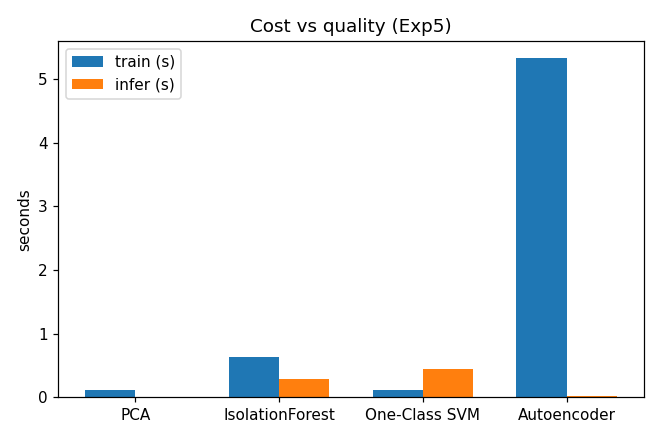

,model,precision,recall,f1,fpr,auroc,auprc,support_benign,support_attack,tn,fp,fn,tp,train_s,infer_s
0,PCA,0.9914,0.6522,0.7868,0.0142,0.9437,0.9781,2400,6000,2366,34,2087,3913,0.11,0.014
1,IsolationForest,0.7170,0.0127,0.0249,0.0125,0.8829,0.9107,2400,6000,2370,30,5924,76,0.63,0.290
2,One-Class SVM,0.9914,0.6937,0.8162,0.0150,0.9835,0.9928,2400,6000,2364,36,1838,4162,0.12,0.439
3,Autoencoder,0.9940,0.8582,0.9211,0.0129,0.9916,0.9966,2400,6000,2369,31,851,5149,5.33,0.019


In [4]:
from IPython.display import Image, display

names = {"PCA": "PCA", "IF": "IsolationForest", "OCSVM": "One-Class SVM", "AE": "Autoencoder"}
rows, per_rows = [], []
for key, model in names.items():
    th = fit_threshold(train_sc[key], "p99")   # same P99 rule for every model
    yp = predict(test_sc[key], th)
    m = evaluate(yte, test_sc[key], yp)
    rows.append({"model": model,
                 **{k: round(v, 4) if isinstance(v, float) else v for k, v in m.items()},
                 "train_s": round(times[key][0], 2), "infer_s": round(times[key][1], 3)})
    tmp = pd.DataFrame({"y_true": yte, "score": test_sc[key], "y_pred": yp,
                        CATEGORY_COL: [BENIGN_LABEL] * len(Xb) + cats[len(Xb):]})
    for _, r in evaluate_per_attack(tmp).iterrows():
        per_rows.append({"model": model, "attack": r["attack"], "recall": round(r["detection_rate"], 4)})
comp = pd.DataFrame(rows)
save_metrics_csv(TAB / "metrics_exp5.csv", comp)
pd.DataFrame(per_rows).to_csv(TAB / "metrics_exp5_per_attack.csv", index=False)
plot_runtime_bars(comp, FIG / "runtime_exp5.png")
display(Image(str(FIG / "runtime_exp5.png")))
comp.round(4)

In [5]:
best = comp.sort_values("f1", ascending=False).iloc[0]
pca = comp[comp.model == "PCA"].iloc[0]
write_experiment_summary(
    REP / "exp5_summary.md", exp_id="Exp5", title="Baseline comparison (identical splits)",
    train_desc=f"same benign-train (n={len(Xtr)}); OCSVM subsampled to {len(sub)}",
    test_desc=f"same test (n={len(yte)})", model_desc="PCA / IF / OCSVM / MLP-AE",
    threshold_desc="each model's own P99-of-train rule (same protocol)",
    metrics=comp.round(4), figures=["runtime_exp5.png"],
    worked=[f"best F1: {best['model']} ({best['f1']:.3f}); PCA trains in {pca['train_s']}s"],
    failed=["IF's score scale misaligns with the shared P99 rule: threshold-free AUROC is competitive, thresholded F1 is not — calibration matters"],
    leakage_note="identical X_train/X_test for all models (EDR §3 Exp5)",
    notebook="notebooks/06_baseline_comparison.ipynb")
print(f"Exp5 done: best={best['model']} F1={best['f1']:.3f}; PCA F1={pca['f1']:.3f}")

Exp5 done: best=Autoencoder F1=0.921; PCA F1=0.787


## Checkpoint — Exp5 verdict

- Nonlinear/boundary models win on F1, but PCA trains in milliseconds on CPU
  and matches them threshold-free on volumetric attacks: **PCA suffices for
  structural floods; stealth/near-manifold traffic justifies the extra cost.**
- IF's collapse under the shared P99 rule (despite fair AUROC) shows thresholds
  do not transfer across model families without recalibration.